In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Load the dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/concrete/compressive/Concrete_Data.xls"
concrete_data = pd.read_excel(url)

# Display the first few rows and check for missing values
print(f"Dataset shape: {concrete_data.shape}")#dataset contains 1030 sampes with 8 features that influence the concrete strength
print(f"Missing values: {concrete_data.isnull().sum().sum()}")

Dataset shape: (1030, 9)
Missing values: 0


In [2]:
concrete_data.head()


,Cement (component 1)(kg in a m^3 mixture),Blast Furnace Slag (component 2)(kg in a m^3 mixture),Fly Ash (component 3)(kg in a m^3 mixture),Water (component 4)(kg in a m^3 mixture),Superplasticizer (component 5)(kg in a m^3 mixture),Coarse Aggregate (component 6)(kg in a m^3 mixture),Fine Aggregate (component 7)(kg in a m^3 mixture),Age (day),"Concrete compressive strength(MPa, megapascals)"
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.986111
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.887366
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.269535
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.052780
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.296075


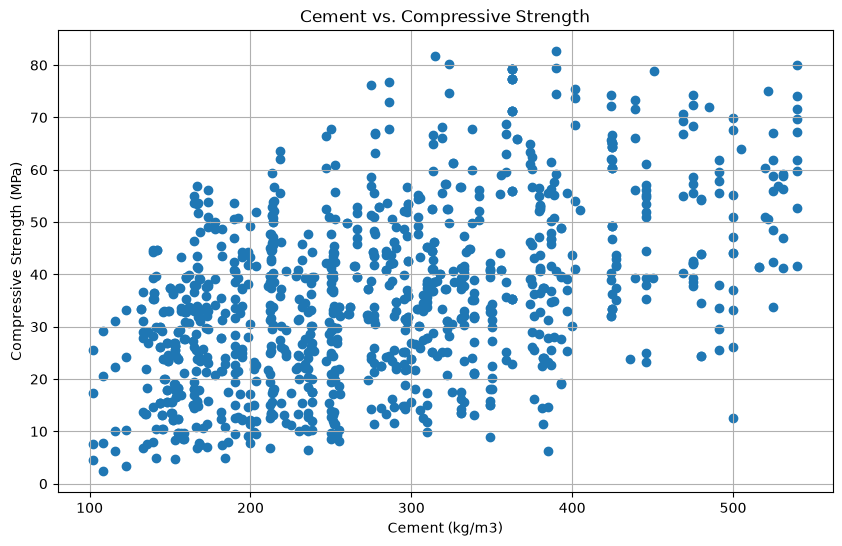

In [3]:
plt.figure(figsize=(10,6))
plt.scatter(concrete_data.iloc[:, 0], concrete_data.iloc[:, -1])
plt.xlabel('Cement (kg/m3)')
plt.ylabel('Compressive Strength (MPa)')
plt.title('Cement vs. Compressive Strength')
plt.grid(True)
plt.show()

In [4]:
#Calculate correlation Matrix
correlation_matrix = concrete_data.corr()
# concrete_data.corr() computes a correlation matrix: a 9Ã—9 table showing how strongly every column relates 
# to every other column. All values are between -1 and 1.

#display the correlation with the target variable
print("Correlation with compressive strength")
print(correlation_matrix.iloc[-1, :-1].sort_values(ascending= False))#last row, all columns

Correlation with compressive strength
Cement (component 1)(kg in a m^3 mixture)                0.497833
Superplasticizer (component 5)(kg in a m^3 mixture)      0.366102
Age (day)                                                0.328877
Blast Furnace Slag (component 2)(kg in a m^3 mixture)    0.134824
Fly Ash (component 3)(kg in a m^3 mixture)              -0.105753
Coarse Aggregate  (component 6)(kg in a m^3 mixture)    -0.164928
Fine Aggregate (component 7)(kg in a m^3 mixture)       -0.167249
Water  (component 4)(kg in a m^3 mixture)               -0.289613
Name: Concrete compressive strength(MPa, megapascals) , dtype: float64


In [5]:
#preparing the data for learning
X = concrete_data.iloc[:, :-1]#all columns except the last
y = concrete_data.iloc[:, -1]#only the last columns

X_array = X.values#convert dataframes to arrays, Pandas Data frames to numpy array
y_array = y.values#Pandas series to numpy array

print(f"Type before conversion: {type(X)}")
print(f"Type after conversion: {X_array}")

#splitting the model into training and testing sets
from sklearn.model_selection import train_test_split#just for having it here
X_train, X_test, y_train, y_test = train_test_split(X_array, y_array, test_size = 0.2, random_state = 42)

print(f"Training set shape: {X_train.shape}")


Type before conversion: <class 'pandas.DataFrame'>
Type after conversion: [[ 540.     0.     0.  ... 1040.   676.    28. ]
 [ 540.     0.     0.  ... 1055.   676.    28. ]
 [ 332.5  142.5    0.  ...  932.   594.   270. ]
 ...
 [ 148.5  139.4  108.6 ...  892.4  780.    28. ]
 [ 159.1  186.7    0.  ...  989.6  788.9   28. ]
 [ 260.9  100.5   78.3 ...  864.5  761.5   28. ]]
Training set shape: (824, 8)


In [6]:
from sklearn.ensemble import RandomForestRegressor
# from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

rf_model = RandomForestRegressor(n_estimators=100, random_state = 42)
rf_model.fit(X_train, y_train)

lr_predictions = lr_model.predict(X_test)
rf_predictions = rf_model.predict(X_test)

models = ["Linear Regression", "Random Forest"]
predictions = [lr_predictions, rf_predictions]#would it not be faster and better to display this as a numpy array

for model_name, pred in zip(models, predictions):
    mse = mean_squared_error(y_test, pred)
    r2 = r2_score(y_test, pred)
    print(f"{model_name}:")
    print(f" Mean squared Error: {mse:.2f}")
    print(f" R2 Score: {r2:.2f}")

Linear Regression:
 Mean squared Error: 95.98
 R2 Score: 0.63
Random Forest:
 Mean squared Error: 30.52
 R2 Score: 0.88


In [7]:
#explanation of the cell above

# mse = mean_squared_error(y_test, pred) â€” compares the real test values against what the model predicted, returns one number (average squared error)
# r2 = r2_score(y_test, pred) â€” measures how much of the variation in concrete strength the model actually explains (0 = useless, 1 = perfect)
# print(f"{model_name}:") â€” prints a label; model_name is a variable passed in from a function, so the same block can evaluate multiple models with different names
# {mse:.2f} and {r2:.2f} â€” 2 decimal places, not factorial. The f stands for "float" and .2 means precision of 2 digits after the decimal. 23.74892 becomes 23.75.

Model with domain knowledge:
  RÂ² Score: 0.89


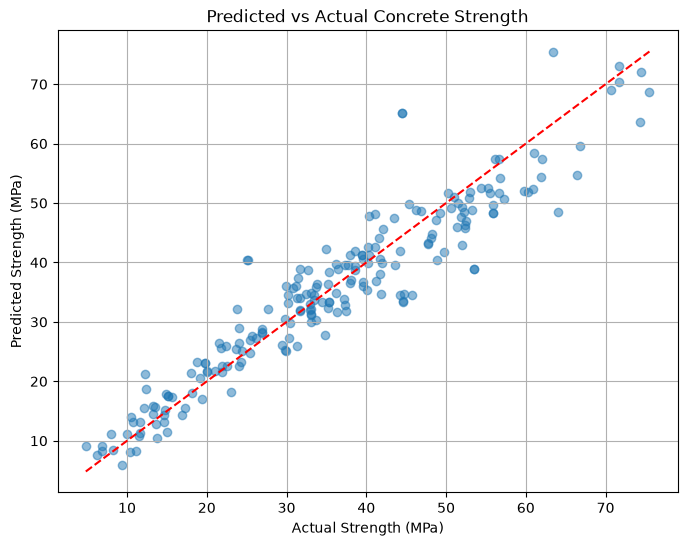

In [8]:
#improving the domain by 
# Use NumPy's efficient arithmetic operations to create domain-specific features
cement_water_ratio = X_train[:, 0] / X_train[:, 3]  # Cement / Water ratio
cement_water_ratio_test = X_test[:, 0] / X_test[:, 3]

# Add this new feature to our feature matrices using NumPy's array manipulation
X_train_enhanced = np.column_stack((X_train, cement_water_ratio))
X_test_enhanced = np.column_stack((X_test, cement_water_ratio_test))

# Train a model with the enhanced features
from sklearn.ensemble import GradientBoostingRegressor
model = GradientBoostingRegressor(n_estimators=100, random_state=42)
model.fit(X_train_enhanced, y_train)
predictions = model.predict(X_test_enhanced)

print(f"Model with domain knowledge:")
print(f"  RÂ² Score: {r2_score(y_test, predictions):.2f}")

# Visualize results
plt.figure(figsize=(8, 6))
plt.scatter(y_test, predictions, alpha=0.5)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'r--')
plt.xlabel('Actual Strength (MPa)')
plt.ylabel('Predicted Strength (MPa)')
plt.title('Predicted vs Actual Concrete Strength')
plt.grid(True)
plt.show()

In [9]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, confusion_matrix,
                             classification_report)

# Bin continuous strength into 3 classes
# 0 = Low (<30 MPa)  1 = Medium (30-50 MPa)  2 = High (>50 MPa)
y_classes = np.digitize(y_array, [30, 50])
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_array, y_classes, test_size=0.2, random_state=42
)

clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train_c, y_train_c)
y_pred_c = clf.predict(X_test_c)

print("Classification Metrics:")
print(f"  Accuracy:  {accuracy_score(y_test_c, y_pred_c):.2f}")
print(f"  Precision: {precision_score(y_test_c, y_pred_c, average='weighted'):.2f}")
print(f"  Recall:    {recall_score(y_test_c, y_pred_c, average='weighted'):.2f}")
print()
print(classification_report(
    y_test_c, y_pred_c,
    target_names=["Low (<30 MPa)", "Medium (30-50 MPa)", "High (>50 MPa)"]
))

Classification Metrics:
  Accuracy:  0.83
  Precision: 0.83
  Recall:    0.83

                    precision    recall  f1-score   support

     Low (<30 MPa)       0.87      0.92      0.89        72
Medium (30-50 MPa)       0.78      0.84      0.81        90
    High (>50 MPa)       0.88      0.66      0.75        44

          accuracy                           0.83       206
         macro avg       0.84      0.81      0.82       206
      weighted avg       0.83      0.83      0.83       206



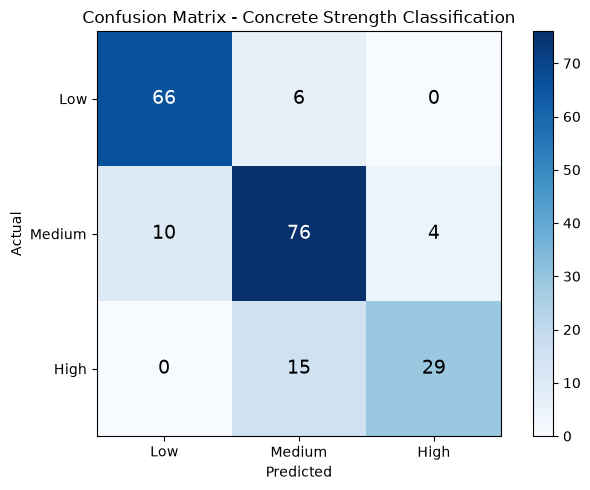

In [10]:
cm = confusion_matrix(y_test_c, y_pred_c)
labels = ["Low", "Medium", "High"]

fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(cm, cmap="Blues")
plt.colorbar(im)
ax.set_xticks([0, 1, 2])
ax.set_yticks([0, 1, 2])
ax.set_xticklabels(labels)
ax.set_yticklabels(labels)
for i in range(3):
    for j in range(3):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black", fontsize=14)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Confusion Matrix - Concrete Strength Classification")
plt.tight_layout()
plt.show()